In [9]:
import os
import sys
import pandas as pd
import lightning as L
import torch.nn as nn
import torch
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tsfresh.utilities.dataframe_functions import (
    roll_time_series,
)
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import ComprehensiveFCParameters
import matplotlib.pylab as plt
from sklearn.preprocessing import MinMaxScaler
from lightning.pytorch.callbacks import EarlyStopping

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from utils.constants import FEATURE_SELECTION_LOG_FILE_BASE
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from visualizer.visualizer import Visualizer

In [2]:
my_logger = Logger(file_name=f"{FEATURE_SELECTION_LOG_FILE_BASE}/vn_index/test")

In [10]:
my_visualizer = Visualizer(logger=my_logger)

In [3]:
my_connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

In [4]:
my_postgresql_driver = PostgreSQLDriver(logger=my_logger)
my_postgresql_driver.connect(my_connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

### VNINDEX

In [5]:
vn_index_df = my_postgresql_driver.select(
    schema_name="stock_market", table_name="vn_index"
)

In [6]:
dtype_map = {
    "date": str,
    "open": float,
    "high": float,
    "low": float,
    "close": float,
    "volume": float,
}

vn_index_df = (
    vn_index_df.astype(dtype_map)
    .dropna(subset=["close"])
    .sort_values(by=["date"])
    .reset_index(drop=True)
)

In [7]:
vn_index_df

,date,open,high,low,close,volume
0,2000-07-28,100.000000,100.000000,100.000000,100.000000,4200.0
1,2000-07-29,100.516667,100.516667,100.516667,100.516667,6233.0
2,2000-07-30,101.033333,101.033333,101.033333,101.033333,8267.0
3,2000-07-31,101.550000,101.550000,101.550000,101.550000,10300.0
4,2000-08-01,102.465000,102.465000,102.465000,102.465000,5300.0
...,...,...,...,...,...,...
9099,2025-06-26,1368.730000,1370.610000,1360.780000,1365.670000,598388700.0
9100,2025-06-27,1369.130000,1373.280000,1362.090000,1371.440000,677408300.0
9101,2025-06-28,1371.340000,1374.620000,1365.403333,1372.983333,663601667.0
9102,2025-06-29,1373.550000,1375.960000,1368.716667,1374.526667,649795033.0


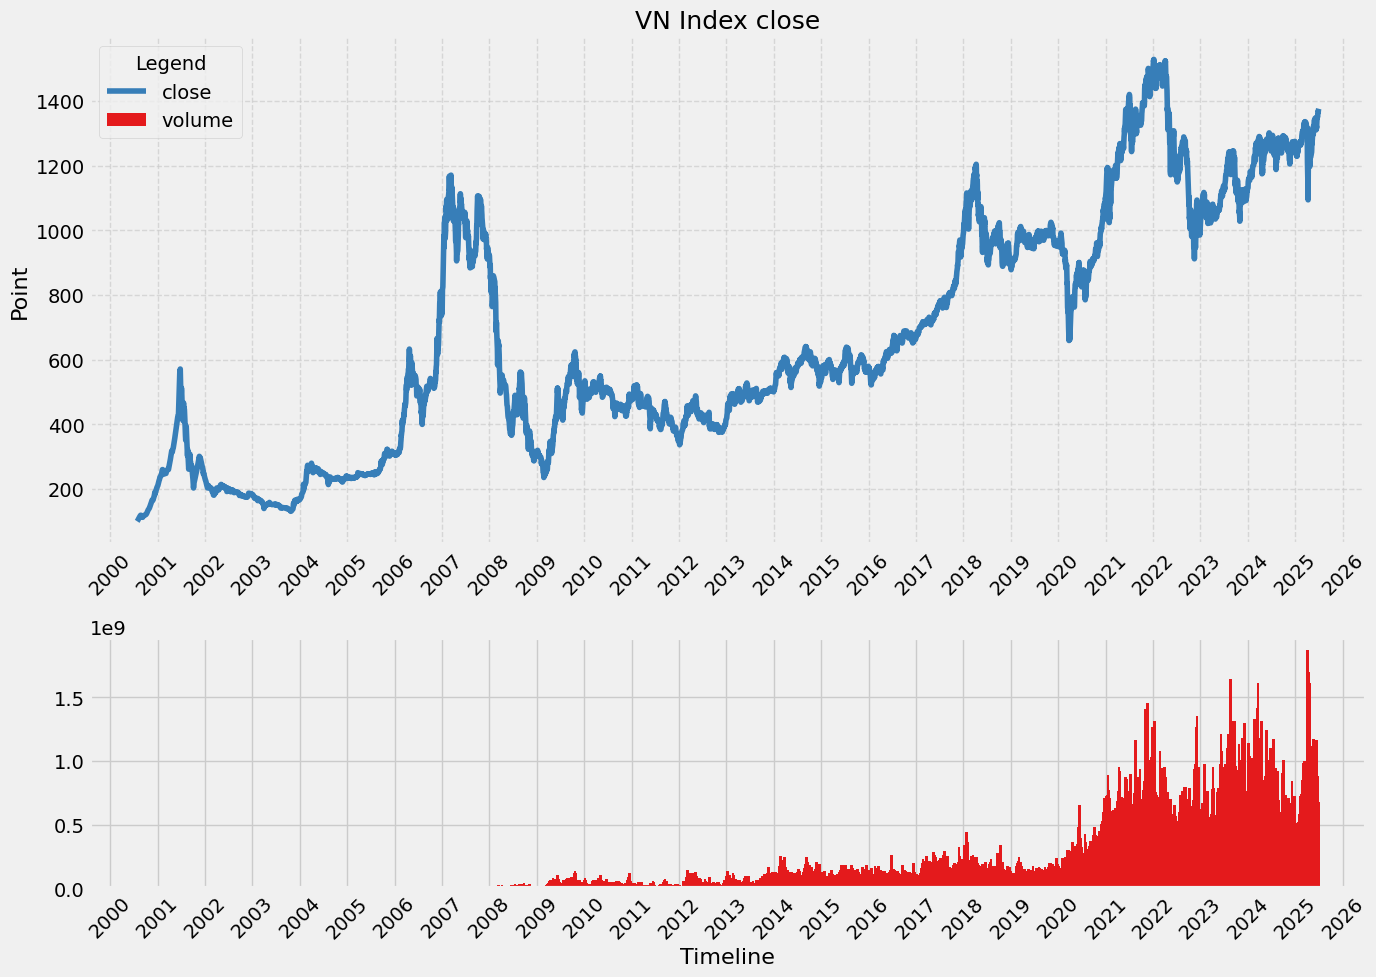

In [15]:
vn_index_fig = my_visualizer.plot_lines_bars_chart(
    vn_index_df,
    x_column="date",
    y_line_columns=["close"],
    y_bar_columns=["volume"],
    title="VN Index close",
    y_line_axis_title="Point",
    y_bar_axis_title="",
    y_unit="",
    prefix_figure_name="vn_index",
    marker=None,
)

### GOLD PRICE

In [40]:
gold_price_df = my_postgresql_driver.select(
    schema_name="macroeconomics", table_name="gold_price"
).dropna(subset=["close"]).sort_values(by=["date"]).reset_index(drop=True)
gold_price_df

,date,close,open,high,low,volume,change
0,2000-01-04,283.7,289.5,289.5,280.0,21620.0,-2.04
1,2000-01-05,282.1,283.7,285.0,281.0,25450.0,-0.56
2,2000-01-06,282.4,281.6,282.8,280.2,19060.0,0.11
3,2000-01-07,282.9,282.5,284.5,282.0,11270.0,0.18
4,2000-01-08,282.8333333333333,282.46666666666664,284.3,281.93333333333334,17713.333333333332,0.09666666666666666
...,...,...,...,...,...,...,...
9305,2025-06-26,3333.9,3333.6,3349.0,3309.2,2060.0,0.15
9306,2025-06-27,3287.6,3341.3,3341.4,3266.5,218870.0,-1.39
9307,2025-06-28,3294.2999999999997,3322.3,3334.8,3261.1666666666665,193980.0,-0.7233333333333333
9308,2025-06-29,3301.0,3303.3,3328.2,3255.8333333333335,169090.0,-0.05666666666666664


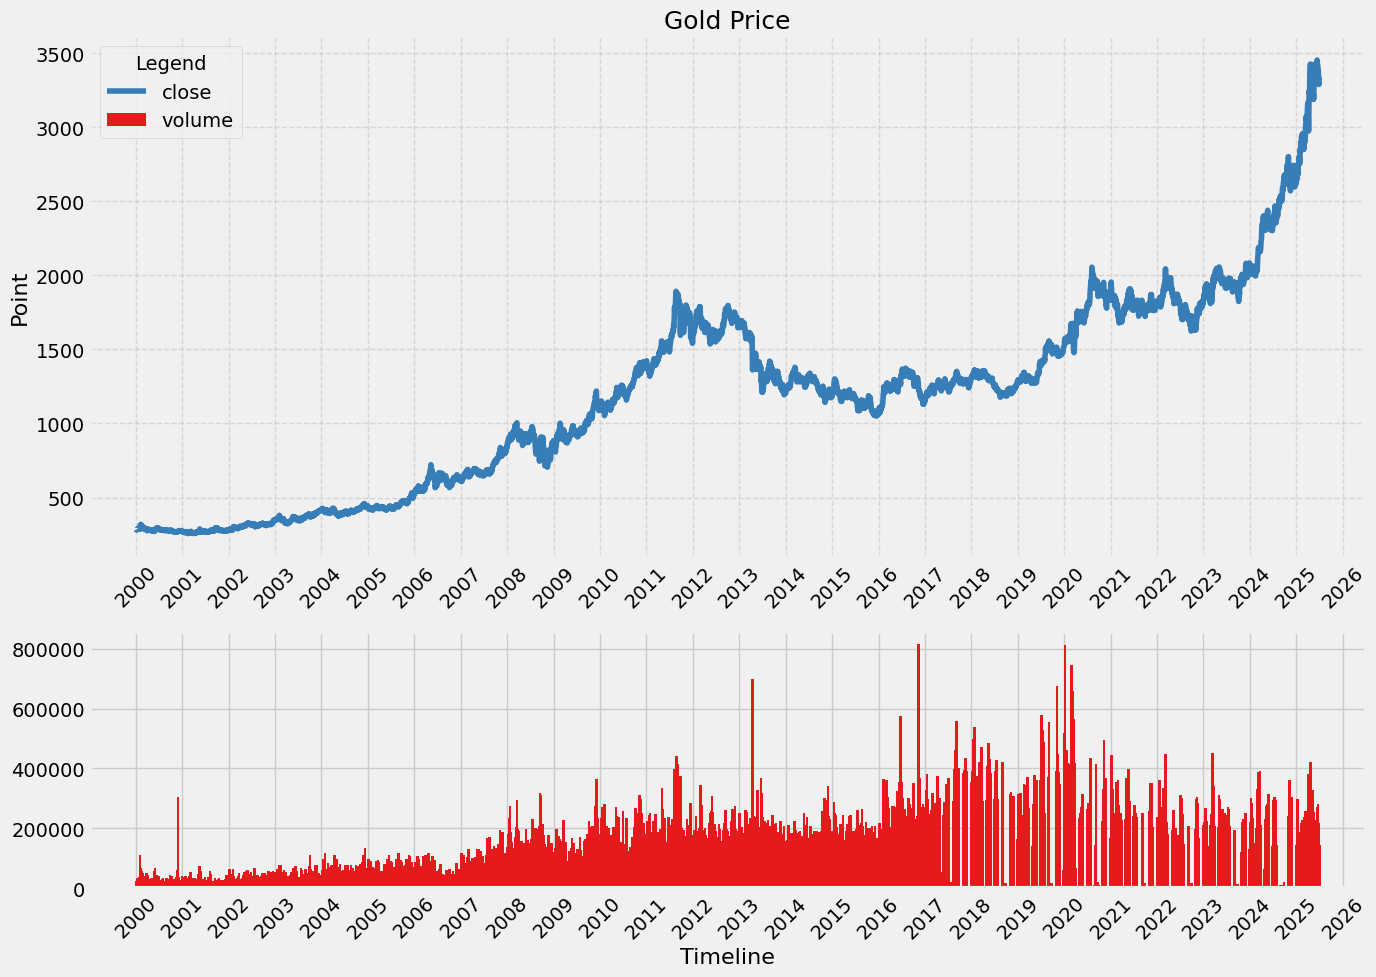

In [41]:
gold_price_fig = my_visualizer.plot_lines_bars_chart(
    gold_price_df,
    x_column="date",
    y_line_columns=["close"],
    y_bar_columns=["volume"],
    title="Gold Price",
    y_line_axis_title="Point",
    y_bar_axis_title="",
    y_unit="",
    prefix_figure_name="",
    marker=None,
)

### FED INTEREST RATE

### OIL PRICE

In [ ]:
oil_price_df = my_postgresql_driver.select(
    schema_name="macroeconomics", table_name="oil_price"
).dropna(subset=["close"]).sort_values(by=["date"]).reset_index(drop=True)
oil_price_df

,date,close,open,high,low,volume,change
0,2000-01-04,24.39,23.9,24.7,23.89,32509.999999999996,-2.75
1,2000-01-05,23.73,24.25,24.37,23.7,30310.0,-2.71
2,2000-01-06,23.62,23.55,24.22,23.35,44660.0,-0.46
3,2000-01-07,23.09,23.57,23.98,23.05,34830.0,-2.24
4,2000-01-08,23.303333333333335,23.393333333333334,23.913333333333334,23.046666666666667,32016.666666666668,-0.5700000000000003
...,...,...,...,...,...,...,...
9305,2025-06-26,67.73,67.77,69.05,67.38,111540.0,0.07
9306,2025-06-27,67.77,67.91,68.42,67.2,93020.0,0.06
9307,2025-06-28,67.71666666666667,67.71666666666667,68.33,67.14333333333333,67710.0,-0.039999999999999994
9308,2025-06-29,67.66333333333333,67.52333333333333,68.24000000000001,67.08666666666667,42400.0,-0.13999999999999999


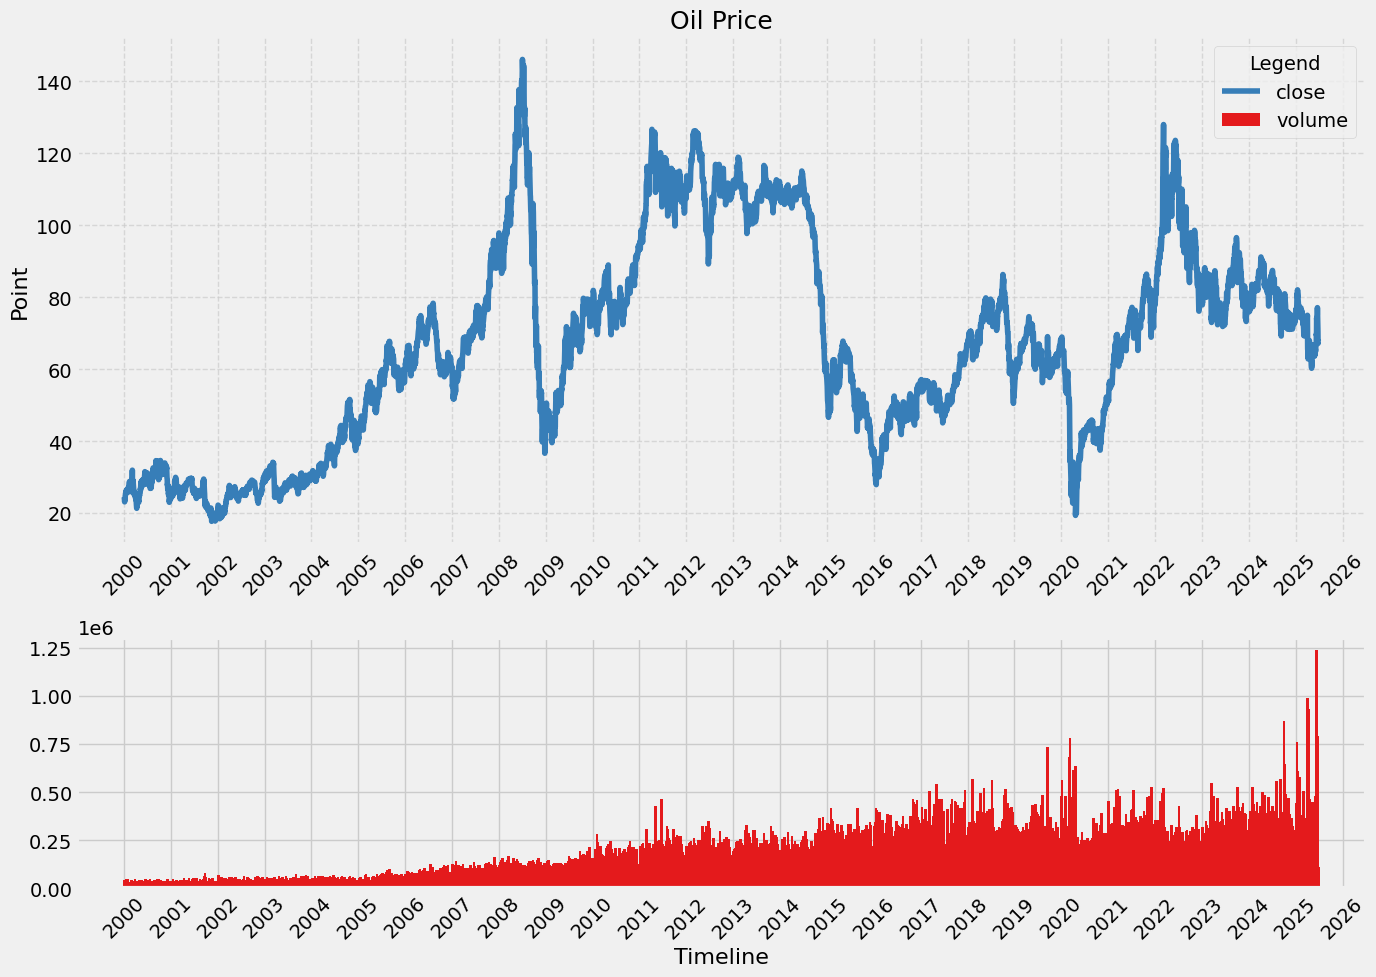

In [28]:
oil_price_fig = my_visualizer.plot_lines_bars_chart(
    oil_price_df,
    x_column="date",
    y_line_columns=["close"],
    y_bar_columns=["volume"],
    title="Oil Price",
    y_line_axis_title="Point",
    y_bar_axis_title="",
    y_unit="",
    prefix_figure_name="",
    marker=None,
)

### NYSE COMPOSITE

In [30]:
nyse_df = my_postgresql_driver.select(
    schema_name="macroeconomics", table_name="nyse_composite"
).dropna(subset=["close"]).sort_values(by=["date"]).reset_index(drop=True)
nyse_df

,date,close,adj_close,open,high,low,volume
0,2000-01-03,6762.11,6762.11,6762.11,6762.11,6762.11,None
1,2000-01-04,6543.76,6543.76,6543.76,6543.76,6543.76,None
2,2000-01-05,6567.03,6567.03,6567.03,6567.03,6567.03,None
3,2000-01-06,6635.44,6635.44,6635.44,6635.44,6635.44,None
4,2000-01-07,6792.67,6792.67,6792.67,6792.67,6792.67,None
...,...,...,...,...,...,...,...
9306,2025-06-26,20256.2,20256.2,20087.45,20273.33,20087.45,5308140000.0
9307,2025-06-27,20338.41,20338.41,20256.2,20435.26,20243.24,7889350000.0
9308,2025-06-28,20368.79,20368.79,20283.603333333333,20437.02333333333,20274.963333333333,7187200000.0
9309,2025-06-29,20399.17,20399.17,20311.006666666668,20438.786666666667,20306.68666666667,6485050000.0


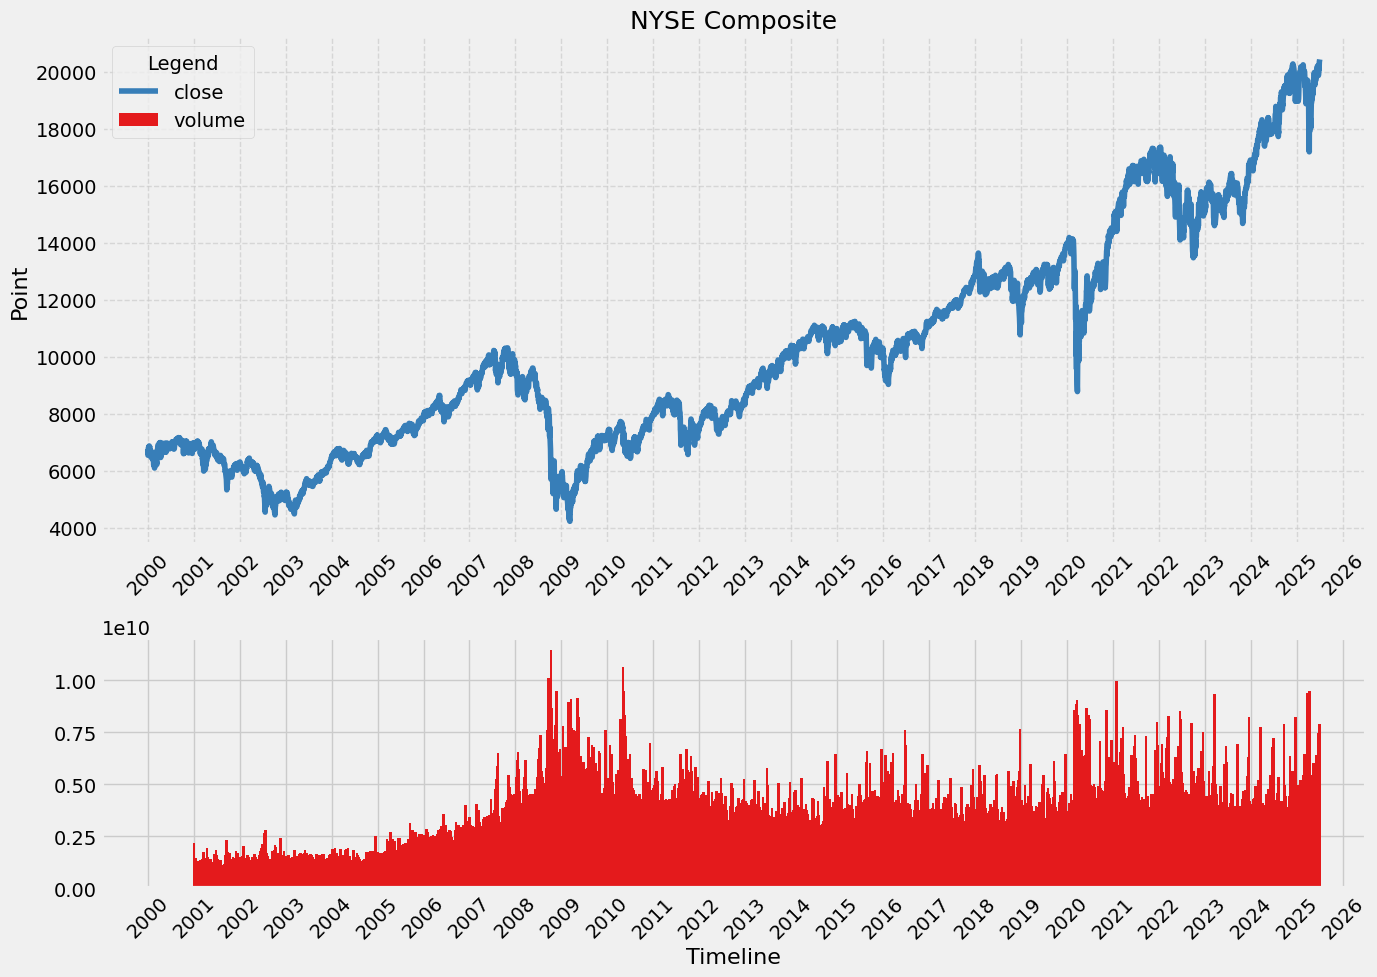

In [32]:
nyse_fig = my_visualizer.plot_lines_bars_chart(
    nyse_df,
    x_column="date",
    y_line_columns=["close"],
    y_bar_columns=["volume"],
    title="NYSE Composite",
    y_line_axis_title="Point",
    y_bar_axis_title="",
    y_unit="",
    prefix_figure_name="",
    marker=None,
)

### EXCHANGE RATE

In [34]:
exchange_rate_df = my_postgresql_driver.select(
    schema_name="macroeconomics", table_name="exchange_rate"
).dropna(subset=["close"]).sort_values(by=["date"]).reset_index(drop=True)
exchange_rate_df

,date,close,open,high,low,volume,change
0,2000-01-03,14027.0,14027.0,14027.0,14027.0,None,0.0
1,2000-01-04,14029.0,14029.0,14029.0,14029.0,None,0.01
2,2000-01-05,14033.0,14033.0,14033.0,14033.0,None,0.03
3,2000-01-06,14032.0,14032.0,14032.0,14032.0,None,-0.01
4,2000-01-07,14032.0,14032.0,14032.0,14032.0,None,0.0
...,...,...,...,...,...,...,...
9306,2025-06-26,26120.0,26140.0,26147.5,26098.5,20.0,-0.13
9307,2025-06-27,26095.0,26120.0,26140.0,26061.5,20.0,-0.1
9308,2025-06-28,26103.5,26107.5,26136.333333333332,26059.333333333332,20.0,-0.03333333333333334
9309,2025-06-29,26112.0,26095.0,26132.666666666668,26057.166666666668,20.0,0.033333333333333326


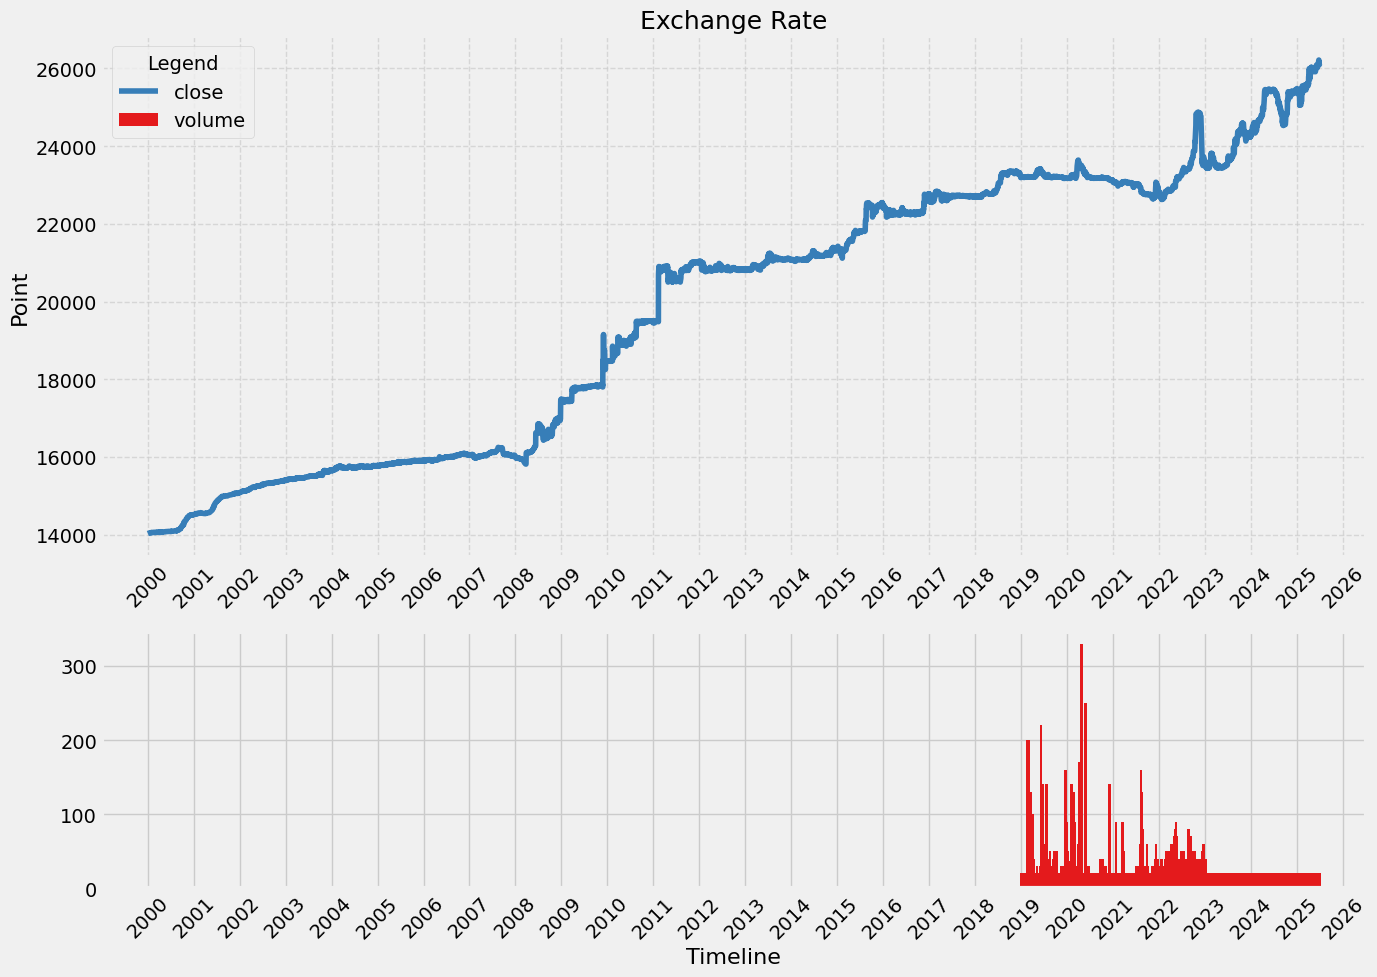

In [36]:
exchange_rate_fig = my_visualizer.plot_lines_bars_chart(
    exchange_rate_df,
    x_column="date",
    y_line_columns=["close"],
    y_bar_columns=["volume"],
    title="Exchange Rate",
    y_line_axis_title="Point",
    y_bar_axis_title="",
    y_unit="",
    prefix_figure_name="",
    marker=None,
)